In [1]:
from pathlib import Path
import pandas as pd

base_dir = Path.cwd()
miami_data_path = base_dir / "archive (1)" / "miami-housing.csv"

if not miami_data_path.exists():
    miami_data_path = base_dir.parent / "archive (1)" / "miami-housing.csv"

if not miami_data_path.exists():
    raise FileNotFoundError(f"CSV not found: {miami_data_path}")

miami_data = pd.read_csv(miami_data_path)
miami_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13932 entries, 0 to 13931
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LATITUDE           13932 non-null  float64
 1   LONGITUDE          13932 non-null  float64
 2   PARCELNO           13932 non-null  int64  
 3   SALE_PRC           13932 non-null  float64
 4   LND_SQFOOT         13932 non-null  int64  
 5   TOT_LVG_AREA       13932 non-null  int64  
 6   SPEC_FEAT_VAL      13932 non-null  int64  
 7   RAIL_DIST          13932 non-null  float64
 8   OCEAN_DIST         13932 non-null  float64
 9   WATER_DIST         13932 non-null  float64
 10  CNTR_DIST          13932 non-null  float64
 11  SUBCNTR_DI         13932 non-null  float64
 12  HWY_DIST           13932 non-null  float64
 13  age                13932 non-null  int64  
 14  avno60plus         13932 non-null  int64  
 15  month_sold         13932 non-null  int64  
 16  structure_quality  139

In [6]:
miami_data.head()

,LATITUDE,LONGITUDE,PARCELNO,SALE_PRC,LND_SQFOOT,TOT_LVG_AREA,SPEC_FEAT_VAL,RAIL_DIST,OCEAN_DIST,WATER_DIST,CNTR_DIST,SUBCNTR_DI,HWY_DIST,age,avno60plus,month_sold,structure_quality
0,25.891031,-80.160561,622280070620,440000.0,9375,1753,0,2815.9,12811.4,347.6,42815.3,37742.2,15954.9,67,0,8,4
1,25.891324,-80.153968,622280100460,349000.0,9375,1715,0,4359.1,10648.4,337.8,43504.9,37340.5,18125.0,63,0,9,4
2,25.891334,-80.153740,622280100470,800000.0,9375,2276,49206,4412.9,10574.1,297.1,43530.4,37328.7,18200.5,61,0,2,4
3,25.891765,-80.152657,622280100530,988000.0,12450,2058,10033,4585.0,10156.5,0.0,43797.5,37423.2,18514.4,63,0,9,4
4,25.891825,-80.154639,622280100200,755000.0,12800,1684,16681,4063.4,10836.8,326.6,43599.7,37550.8,17903.4,42,0,7,4


In [7]:
miami_data.describe()

,LATITUDE,LONGITUDE,PARCELNO,SALE_PRC,LND_SQFOOT,TOT_LVG_AREA,SPEC_FEAT_VAL,RAIL_DIST,OCEAN_DIST,WATER_DIST,CNTR_DIST,SUBCNTR_DI,HWY_DIST,age,avno60plus,month_sold,structure_quality
count,13932.000000,13932.000000,1.393200e+04,1.393200e+04,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000
mean,25.728811,-80.327475,2.356496e+12,3.999419e+05,8620.879917,2058.044574,9562.493468,8348.548715,31690.993798,11960.285235,68490.327132,41115.047265,7723.770693,30.669251,0.014930,6.655828,3.513997
std,0.140633,0.089199,1.199290e+12,3.172147e+05,6070.088742,813.538535,13890.967782,6178.027333,17595.079468,11932.992369,32008.474808,22161.825935,6068.936108,21.153068,0.121276,3.301523,1.097444
min,25.434333,-80.542172,1.020008e+11,7.200000e+04,1248.000000,854.000000,0.000000,10.500000,236.100000,0.000000,3825.600000,1462.800000,90.200000,0.000000,0.000000,1.000000,1.000000
25%,25.620056,-80.403278,1.079160e+12,2.350000e+05,5400.000000,1470.000000,810.000000,3299.450000,18079.350000,2675.850000,42823.100000,23996.250000,2998.125000,14.000000,0.000000,4.000000,2.000000
50%,25.731810,-80.338911,3.040300e+12,3.100000e+05,7500.000000,1877.500000,2765.500000,7106.300000,28541.750000,6922.600000,65852.400000,41109.900000,6159.750000,26.000000,0.000000,7.000000,4.000000
75%,25.852269,-80.258019,3.060170e+12,4.280000e+05,9126.250000,2471.000000,12352.250000,12102.600000,44310.650000,19200.000000,89358.325000,53949.375000,10854.200000,46.000000,0.000000,9.000000,4.000000
max,25.974382,-80.119746,3.660170e+12,2.650000e+06,57064.000000,6287.000000,175020.000000,29621.500000,75744.900000,50399.800000,159976.500000,110553.800000,48167.300000,96.000000,1.000000,12.000000,5.000000


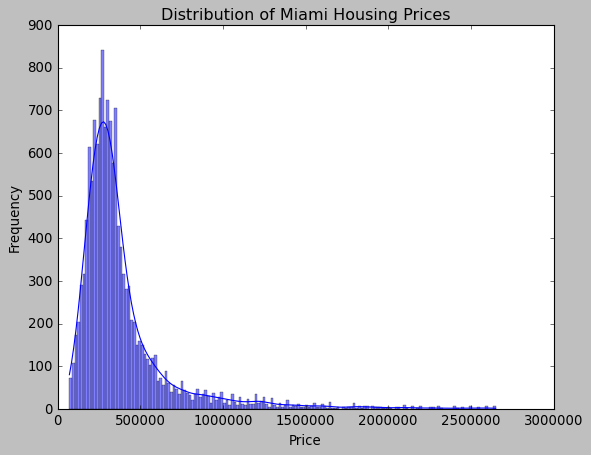

In [5]:
import matplotlib.pyplot as plt
plt.style.use('classic')
import seaborn as sns

# Plot the distribution of Miami housing prices, left skewed thus most prices are concentrated on the lower end
fig, ax = plt.subplots()
sns.histplot(miami_data['SALE_PRC'], kde=True, ax=ax)
ax.set_title('Distribution of Miami Housing Prices')
ax.set_xlabel('Price')
ax.set_ylabel('Frequency')
plt.show()


In [7]:
import plotly.express as px

#Put houses in a price range and assort by color 
miami_data['PRICE_RANGE'] = pd.cut(miami_data['SALE_PRC'], bins=[0, 200000, 400000, 600000, 800000, 1000000, 2000000, 5000000], labels=['0-200k', '200k-400k', '400k-600k', '600k-800k', '800k-1M', '1M-2M', '2M-5M'])

#Plot the longitude and lattitude on the map using a color to represent the sq ft
fig = px.scatter_mapbox(miami_data,
                        lat="LATITUDE",
                        lon="LONGITUDE",
                        size="LND_SQFOOT",
                        color="PRICE_RANGE",
                        color_discrete_sequence=px.colors.qualitative.Plotly,
                        size_max=18,
                        zoom=10,
                        hover_name="SALE_PRC",
                        hover_data = ["LND_SQFOOT", "PRICE_RANGE"]
                        )

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

In [15]:
# Use a log-scaled y-axis and bubble sizing so the expensive homes stand out without flattening the smaller ones
fig2 = px.scatter(
    miami_data,
    x="LND_SQFOOT",
    y="SALE_PRC",
    color="PRICE_RANGE",
    size="LND_SQFOOT",
    size_max=18,
    opacity=0.7,
    log_y=True,
    color_discrete_sequence=px.colors.qualitative.Plotly,
    hover_name="SALE_PRC",
    hover_data=["LND_SQFOOT", "PRICE_RANGE"],
    title="Miami Home Price vs Lot Size (log-scaled)"
)
fig2.update_layout(
    template="plotly_white",
    xaxis_title="Lot Size (sq ft)",
    yaxis_title="Sale Price",
    legend_title="Price Range",
    margin={"r": 10, "t": 40, "l": 10, "b": 10}
)
fig2.show()


<Axes: >

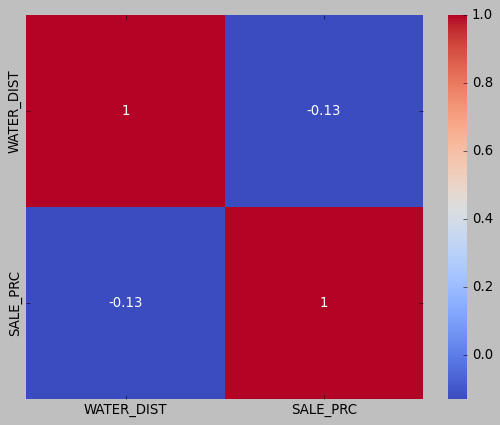

In [16]:
#Comparing the features of water distance to the price to see if it has any causality in driving the prices. 

import seaborn as sns

miami_data[["WATER_DIST", "SALE_PRC"]].corr()

#Visualizing the relationship between water distance and sale price by using a heat map 
sns.heatmap(miami_data[["WATER_DIST", "SALE_PRC"]].corr(), annot=True, cmap="coolwarm")